## Volumetric analysis (OHBM)

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from env.imports import *

/ext3/miniconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
2025-12-22 17:32:23.607886: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-22 17:32:24.668727: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-22 17:32:25.221156: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-22 17:32:25.224137: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instruc

In [3]:
import importlib
import data

import models
import sim.sim
import sim.sim_utils
from sim.sim_utils import bytes2human, print_system_usage
from sim.sim import Simulation
from sim.sim_run import single_sim_run

importlib.reload(sim.sim)
importlib.reload(sim.sim_run)
importlib.reload(models.train_val)
importlib.reload(data.data_utils)


Resorting genes by reference genome order
Resorting genes by reference genome order


<module 'data.data_utils' from '/scratch/asr655/neuroinformatics/GeneEx2Conn/data/data_utils.py'>

#### Check job specs

In [4]:
print_system_usage()

total = psutil.disk_usage('/').total
print(bytes2human(total))

CPU Usage: 47.0%
RAM Usage: 37.1%
Available RAM: 633.0G
Total RAM: 1007.0G
52.4G


In [5]:
print(os.environ.get("CUDA_VISIBLE_DEVICES"))

# Check available GPUs
print(f"Available GPUs: {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)} - Memory Allocated: {torch.cuda.memory_allocated(i)/1024**3:.2f} GB")


None
Available GPUs: 1
GPU 0: NVIDIA A100-SXM4-80GB - Memory Allocated: 0.00 GB


In [6]:
print("XGBoost version:", xgboost.__version__)
print("cupy version:", cp.__version__)

GPUtil.getAvailable()

# if a number is seen a GPU is available
GPUtil.getGPUs()

DEVICE_ID_LIST = GPUtil.getFirstAvailable()
DEVICE_ID = DEVICE_ID_LIST[0] # grab first element from list
if DEVICE_ID != None: 
    print('GPU found', DEVICE_ID)
    use_gpu = True

    GPUtil.showUtilization()

XGBoost version: 2.0.3
cupy version: 13.1.0
GPU found 0
| ID | GPU | MEM |
------------------
|  0 |  0% |  0% |


In [7]:
torch.cuda.is_available()

# Clear GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Load data for left cortical areas only and predict SC as a function of volume

In [106]:
from data.data_load import load_transcriptome, load_coords, load_connectome
from sim.null import exp_decay

# Load data
X = load_transcriptome(parcellation='S456', gene_list='0.2', sort_genes='refgenome', omit_subcortical=True, hemisphere='left')
coords = load_coords(parcellation='S456', omit_subcortical=True, hemisphere='left')
Y = load_connectome(parcellation='S456', dataset='HCP', measure='SC', omit_subcortical=True, hemisphere='left')

# Remove rows that are all NaN
valid_indices = ~np.isnan(X).all(axis=1)
# valid_indices = np.ones(X.shape[0], dtype=bool)

# Subset data using valid indices
X = X[valid_indices]
coords = coords[valid_indices]

# EXPONENTIAL DECAY COMPUTED FROM FLIPPED COORDINATES TO CREATE SINGLE HEMISPHERE
coords[:,0] = -np.abs(coords[:,0])  # Take negative of absolute value of x coordinates

Y = Y[valid_indices][:, valid_indices]

# Compute pairwise distances between coordinates
n_regions = len(coords)
distances = cdist(coords, coords)

# Get upper triangle indices to extract distances and FC values
triu_indices = np.triu_indices_from(distances, k=1)
d = distances[triu_indices]
fc = Y[triu_indices]

Resorting genes by reference genome order


## Compute volume per ROI

In [107]:
import nibabel as nb
import numpy as np
import pandas as pd
from nilearn.input_data import NiftiLabelsMasker

# Path to the atlas NIfTI
atlas_nii_path = '/scratch/asr655/neuroinformatics/GeneEx2Conn_data/Penn_UKBB_data/atlases/atlas-4S456Parcels/atlas-4S456Parcels_space-MNI152NLin6Asym_dseg.nii.gz'
# Path to atlas metadata
atlas_meta_path = './data/atlases/atlas-4S456Parcels_dseg_reformatted.csv'

# Load atlas image
img = nb.load(atlas_nii_path)
img_data = img.get_fdata()
voxel_size = img.header.get_zooms()
voxel_volume = voxel_size[0] * voxel_size[1] * voxel_size[2]

# Load metadata
atlas_meta = pd.read_csv(atlas_meta_path)
# Assume column 'id' is label index (starting at 1), and 'label' is parcel name
# We'll use 'id' to match labels in the NIfTI image
parcel_labels = atlas_meta['label']
parcel_indices = atlas_meta['id']

# For each unique label value (should correspond to 1..N as region ids)
parcel_volumes_voxels = {}
for i, label_val in enumerate(parcel_indices):
    count = np.sum(img_data == label_val)
    parcel_volumes_voxels[parcel_labels.iloc[i]] = count

# Convert voxel counts to physical volume (mm^3)
parcel_volumes_physical = {label: count * voxel_volume for label, count in parcel_volumes_voxels.items()}

# Store results in a DataFrame
df_volumes = pd.DataFrame({
    "parcel": list(parcel_volumes_voxels.keys()),
    "voxel_count": list(parcel_volumes_voxels.values()),
    "volume_mm3": [parcel_volumes_physical[l] for l in parcel_volumes_voxels.keys()]
})

print(df_volumes.head())

     parcel  voxel_count  volume_mm3
0  LH_Vis_1          347      2776.0
1  LH_Vis_2          425      3400.0
2  LH_Vis_3          309      2472.0
3  LH_Vis_4          401      3208.0
4  LH_Vis_5          426      3408.0


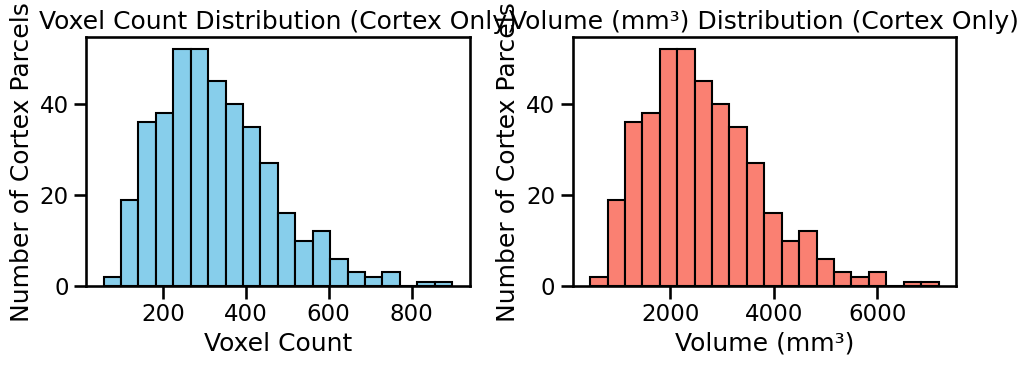

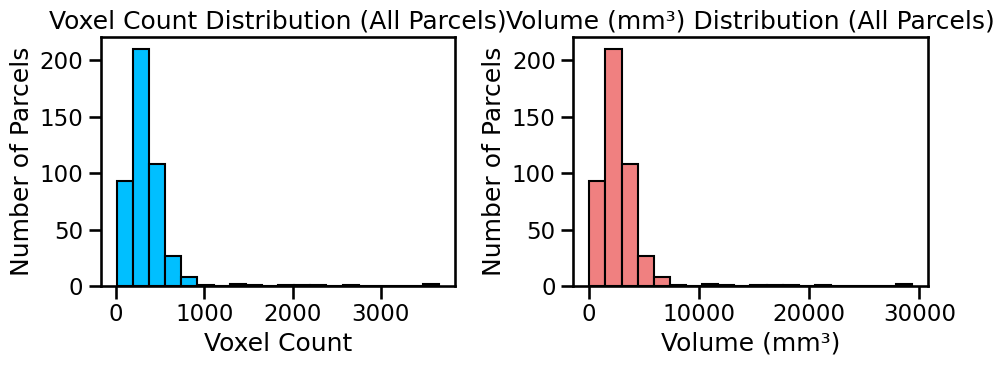

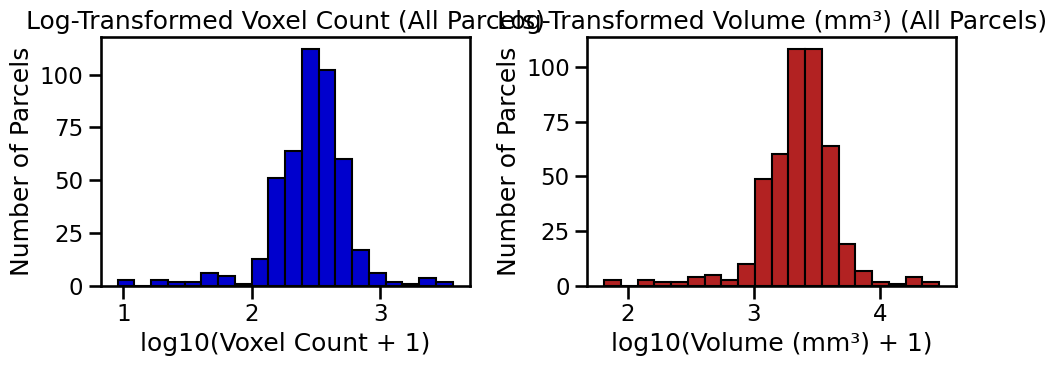

In [108]:
import matplotlib.pyplot as plt

# --- First 400 parcels (Cortex only) ---
df_cortex = df_volumes.iloc[:400]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_cortex['voxel_count'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Voxel Count')
plt.ylabel('Number of Cortex Parcels')
plt.title('Voxel Count Distribution (Cortex Only)')

plt.subplot(1, 2, 2)
plt.hist(df_cortex['volume_mm3'], bins=20, color='salmon', edgecolor='black')
plt.xlabel('Volume (mm³)')
plt.ylabel('Number of Cortex Parcels')
plt.title('Volume (mm³) Distribution (Cortex Only)')

plt.tight_layout()
plt.show()

# --- Then for all parcels ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_volumes['voxel_count'], bins=20, color='deepskyblue', edgecolor='black')
plt.xlabel('Voxel Count')
plt.ylabel('Number of Parcels')
plt.title('Voxel Count Distribution (All Parcels)')

plt.subplot(1, 2, 2)
plt.hist(df_volumes['volume_mm3'], bins=20, color='lightcoral', edgecolor='black')
plt.xlabel('Volume (mm³)')
plt.ylabel('Number of Parcels')
plt.title('Volume (mm³) Distribution (All Parcels)')

plt.tight_layout()
plt.show()

# --- Log-Transformed Histogram ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
voxel_counts_log = np.log10(np.array(df_volumes['voxel_count']) + 1)
plt.hist(voxel_counts_log, bins=20, color='mediumblue', edgecolor='black')
plt.xlabel('log10(Voxel Count + 1)')
plt.ylabel('Number of Parcels')
plt.title('Log-Transformed Voxel Count (All Parcels)')

plt.subplot(1, 2, 2)
volume_mm3_log = np.log10(np.array(df_volumes['volume_mm3']) + 1)
plt.hist(volume_mm3_log, bins=20, color='firebrick', edgecolor='black')
plt.xlabel('log10(Volume (mm³) + 1)')
plt.ylabel('Number of Parcels')
plt.title('Log-Transformed Volume (mm³) (All Parcels)')

plt.tight_layout()
plt.show()

In [109]:
volumes = np.array(df_volumes['volume_mm3'][:200])
# volumes = np.array(df_volumes['volume_mm3'][valid_indices])

In [110]:
import numpy as np
from scipy import sparse
from sklearn.linear_model import RidgeCV

def fit_focal_volumetric_model(volumes, Y, symmetric=True, lambdas=None, eps=1e-6, omit_subcortical=False):
    """
    Fit a focal volumetric baseline on a connectome using Fisher-z.
    
    
    Symmetric model (undirected; diag ignored):
        Z_ij = b + alpha_i * log(v_i) + alpha_j * log(v_j)

    Asymmetric model (directed; diag ignored):
        Z_ij = b + alpha_i * log(v_i) + gamma_j * log(v_j)

    Parameters
    ----------
    volumes : (r,) array
        Positive ROI volumes.
    Y : (r, r) array
        Connectivity matrix with values in [-1, 1].
    symmetric : bool
        If True, fit symmetric model (one parameter per ROI). If False, fit asymmetric model
        (two parameters per ROI: source alpha and target gamma).
    lambdas : array-like or None
        Ridge penalties to cross-validate over. Defaults to logspace(-4, 4, 25).
    eps : float
        Clipping tolerance for Fisher-z transform.
    omit_subcortical : bool
        If True, only use parcels up to the nearest hundred (i.e., keep first 100, 200, etc).

    Returns
    -------
    results : dict
        If symmetric=True:
            {
              'alpha'     : (r,) node coefficients,
              'intercept' : scalar,
              'Y_hat'     : (r,r) symmetric predictions, diag=NaN,
              'lambda'    : chosen ridge penalty,
              'symmetric' : True
            }

        If symmetric=False:
            {
              'alpha'     : (r,) source coefficients,
              'gamma'     : (r,) target coefficients,
              'intercept' : scalar,
              'Y_hat'     : (r,r) directed predictions, diag=NaN,
              'lambda'    : chosen ridge penalty,
              'symmetric' : False
            }
    """
    r = Y.shape[0]
    assert Y.shape == (r, r), f"Expected Y shape (r,r); got {Y.shape}"
    assert volumes.shape == (r,), f"Expected volumes shape (r,); got {volumes.shape}"
    if np.any(volumes <= 0):
        raise ValueError("All volumes must be > 0 to take log(volumes).")

    # If omit_subcortical, drop any data after the nearest hundred
    if omit_subcortical:
        # Nearest lower hundred, e.g. 178 -> 100, 235 -> 200, 300 -> 300
        limit = (r // 100) * 100
        if limit < 1:
            raise ValueError("Not enough ROIs to omit subcortical regions.")
        Y = Y[:limit, :limit]
        volumes = volumes[:limit]
        r = limit

    # Fisher-z transform (clip for numerical stability near +/-1)
    Yc = np.clip(Y, -1 + eps, 1 - eps)
    Z = np.arctanh(Yc)

    # log-volumes (centered for stability / interpretability)
    x = np.log(volumes)
    x -= x.mean()

    if lambdas is None:
        lambdas = np.logspace(-4, 4, 25)

    if symmetric:
        # ---- edges: undirected upper triangle only (ignore diagonal) ----
        iu, ju = np.triu_indices(r, k=1)
        y = Z[iu, ju]
        m = y.shape[0]

        # ---- sparse design matrix: [intercept | alpha_0..alpha_{r-1}] ----
        rows = np.arange(m)
        data = np.concatenate([np.ones(m), x[iu], x[ju]])
        cols = np.concatenate([np.zeros(m, dtype=int), 1 + iu, 1 + ju])
        row_idx = np.concatenate([rows, rows, rows])

        X = sparse.coo_matrix((data, (row_idx, cols)), shape=(m, 1 + r)).tocsr()

        model = RidgeCV(alphas=lambdas, fit_intercept=False)
        model.fit(X, y)

        w = model.coef_
        b_hat = w[0]
        alpha_hat = w[1:]

        # ---- predict and rebuild symmetric matrix (diag ignored => NaN) ----
        Z_hat = model.predict(X)
        Y_hat_edges = np.tanh(Z_hat)

        Y_hat = np.full_like(Y, np.nan, dtype=float)
        Y_hat[iu, ju] = Y_hat_edges
        Y_hat[ju, iu] = Y_hat_edges  # enforce symmetry

        return {
            "alpha": alpha_hat,
            "intercept": b_hat,
            "Y_hat": Y_hat,
            "lambda": model.alpha_,
            "symmetric": True,
        }

    else:
        # ---- edges: all directed off-diagonal (ignore diagonal) ----
        ii, jj = np.where(~np.eye(r, dtype=bool))
        y = Z[ii, jj]
        m = y.shape[0]

        # ---- sparse design matrix: [intercept | alpha_0..alpha_{r-1} | gamma_0..gamma_{r-1}] ----
        rows = np.arange(m)
        data = np.concatenate([np.ones(m), x[ii], x[jj]])
        cols = np.concatenate([
            np.zeros(m, dtype=int),   # intercept
            1 + ii,                   # alpha (source)
            1 + r + jj                # gamma (target)
        ])
        row_idx = np.concatenate([rows, rows, rows])

        X = sparse.coo_matrix((data, (row_idx, cols)), shape=(m, 1 + 2 * r)).tocsr()

        model = RidgeCV(alphas=lambdas, fit_intercept=False)
        model.fit(X, y)

        w = model.coef_
        b_hat = w[0]
        alpha_hat = w[1:1 + r]
        gamma_hat = w[1 + r:1 + 2 * r]

        # ---- predict directed matrix (diag ignored => NaN) ----
        Z_hat = model.predict(X)
        Y_hat_edges = np.tanh(Z_hat)

        Y_hat = np.full_like(Y, np.nan, dtype=float)
        Y_hat[ii, jj] = Y_hat_edges  # not forced symmetric

        return {
            "alpha": alpha_hat,
            "gamma": gamma_hat,
            "intercept": b_hat,
            "Y_hat": Y_hat,
            "lambda": model.alpha_,
            "symmetric": False,
        }

In [111]:
focal_dict_sym = fit_focal_volumetric_model(volumes, Y, symmetric=True, lambdas=None, eps=1e-6, omit_subcortical=False)
focal_dict_asym = fit_focal_volumetric_model(volumes, Y, symmetric=False, lambdas=None, eps=1e-6, omit_subcortical=False)

In [112]:
np.allclose(focal_dict_asym['Y_hat'], focal_dict_sym['Y_hat'], equal_nan=True, atol=1e-3, rtol=1e-3)

True

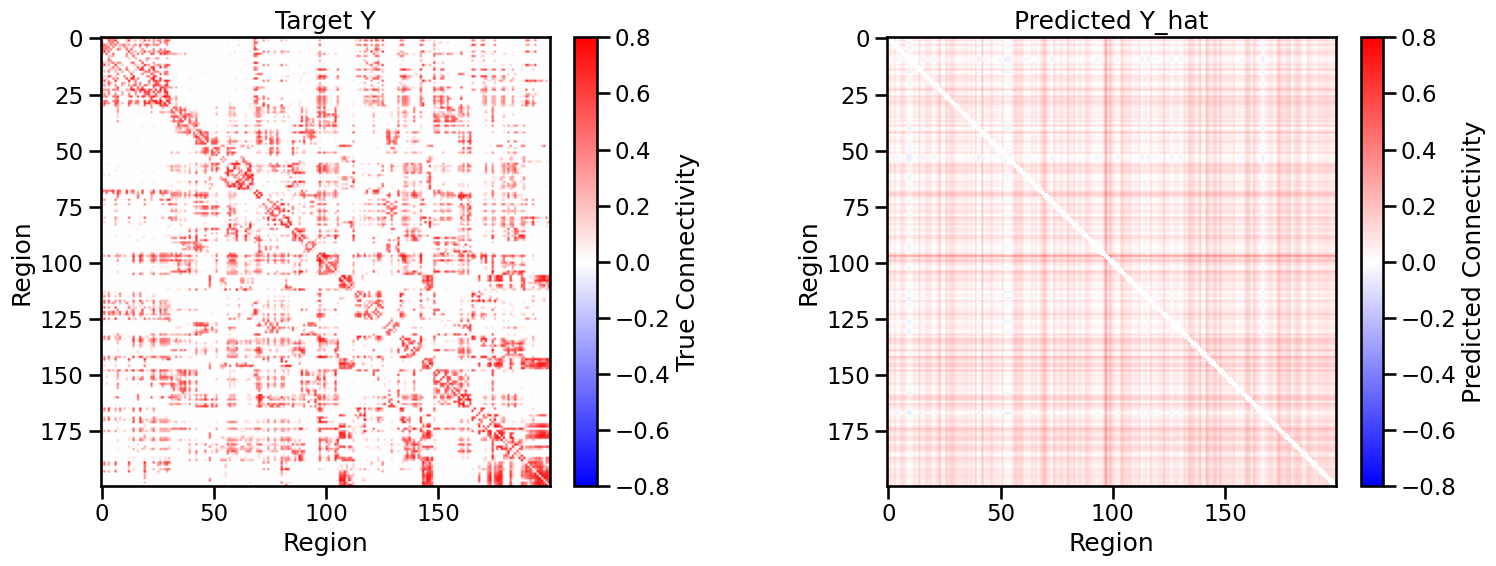

Correlation between target and prediction: 0.335


In [113]:
focal_dict = focal_dict_asym
omit_subcortical = False  # Set this depending on your use-case or logic
Y_hat = focal_dict['Y_hat']

if omit_subcortical:
    Y_plot = Y[:400, :400]
    Y_hat_plot = Y_hat[:400, :400]
else:
    Y_plot = Y
    Y_hat_plot = Y_hat

# Plot predicted and true side-by-side
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

im0 = axs[0].imshow(Y_plot, cmap='bwr', vmin=-0.8, vmax=0.8)
axs[0].set_title('Target Y')
axs[0].set_xlabel('Region')
axs[0].set_ylabel('Region')
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04, label='True Connectivity')

im1 = axs[1].imshow(Y_hat_plot, cmap='bwr', vmin=-0.8, vmax=0.8)
axs[1].set_title('Predicted Y_hat')
axs[1].set_xlabel('Region')
axs[1].set_ylabel('Region')
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04, label='Predicted Connectivity')

plt.tight_layout()
plt.show()

# Compute correlation (ignoring nan, upper triangle only, off-diagonal)
mask = ~np.eye(Y_plot.shape[0], dtype=bool)
y_true = Y_plot[mask]
y_pred = Y_hat_plot[mask]

# Remove nan pairs
valid = ~np.isnan(y_true) & ~np.isnan(y_pred)
corr = np.corrcoef(y_true[valid], y_pred[valid])[0,1]
print(f"Correlation between target and prediction: {corr:.3f}")

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def fit_focal_roi_coeffs(i, volumes, Y, eps=1e-6, l2=0.0, plot=True):
    """
    Focal per-ROI fit (no intercept), directed from source i to all targets j != i:

        Z_ij = alpha_i * log(v_i) + gamma_i * log(v_j)

    with Z_ij = arctanh(Y_ij). Fits (alpha_i, gamma_i) using numeric optimization.

    Parameters
    ----------
    i : int
        Source ROI index.
    volumes : (r,) array
        Positive ROI volumes.
    Y : (r, r) array
        Connectivity in [-1,1] (can include NaNs).
    eps : float
        Clip for arctanh stability.
    l2 : float
        Optional L2 penalty on (alpha, gamma) to stabilize fits (default 0.0).
    plot : bool
        If True, plot true vs predicted with Pearson r.

    Returns
    -------
    out : dict
        {
          'alpha': float,
          'gamma': float,
          'pearson_r': float,
          'j_idx': (m,) target indices used,
          'z_true': (m,) true Fisher-z values,
          'z_pred': (m,) predicted Fisher-z values
        }
    """
    r = Y.shape[0]
    assert Y.shape == (r, r)
    assert volumes.shape == (r,)
    if np.any(volumes <= 0):
        raise ValueError("All volumes must be > 0 to take log(volumes).")

    # Fisher-z transform
    Yc = np.clip(Y, -1 + eps, 1 - eps)
    Z = np.arctanh(Yc)

    # Targets j != i
    j_idx = np.arange(r)
    j_idx = j_idx[j_idx != i]

    z_true = Z[i, j_idx]
    xj = np.log(volumes[j_idx])
    xi = np.log(volumes[i])  # constant regressor for this focal problem

    if not np.isfinite(xi) or xi == 0.0:
        raise ValueError(
            f"log(volumes[i]) is {xi}. This model needs log(v_i) != 0 (i.e., v_i != 1 in your units)."
        )

    # Drop non-finite edges
    mask = np.isfinite(z_true) & np.isfinite(xj)
    z_true = z_true[mask]
    xj = xj[mask]
    j_idx = j_idx[mask]

    if z_true.size < 5:
        raise ValueError(f"Not enough finite edges for ROI {i} (got {z_true.size}).")

    # Objective: SSE + optional L2
    def obj(theta):
        alpha, gamma = theta
        z_pred = alpha * xi + gamma * xj
        resid = z_true - z_pred
        return np.sum(resid * resid) + l2 * (alpha * alpha + gamma * gamma)

    # Initialize near zero
    theta0 = np.array([0.0, 0.0], dtype=float)

    res = minimize(obj, theta0, method="L-BFGS-B")
    if not res.success:
        raise RuntimeError(f"Optimization failed for ROI {i}: {res.message}")

    alpha_hat, gamma_hat = res.x
    z_pred = alpha_hat * xi + gamma_hat * xj

    # Pearson correlation (avoid scipy.stats dependency)
    zt = z_true - z_true.mean()
    zp = z_pred - z_pred.mean()
    denom = np.sqrt(np.sum(zt * zt) * np.sum(zp * zp))
    pearson_r = float(np.sum(zt * zp) / denom) if denom > 0 else np.nan

    if plot:
        plt.figure()
        plt.scatter(z_true, z_pred, s=12)
        plt.xlabel("True Fisher-z (Z_ij)")
        plt.ylabel("Pred Fisher-z (Ẑ_ij)")
        plt.title(f"ROI {i}: true vs pred (Pearson r = {pearson_r:.3f})")
        plt.tight_layout()
        plt.show()

    return {
        "alpha": float(alpha_hat),
        "gamma": float(gamma_hat),
        "pearson_r": pearson_r,
        "j_idx": j_idx,
        "z_true": z_true,
        "z_pred": z_pred,
    }

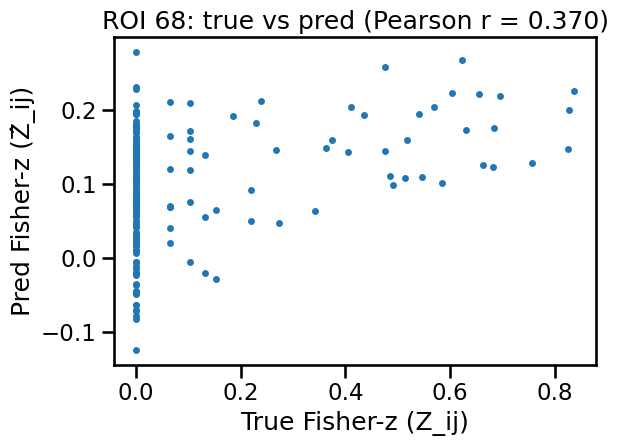

-0.16490790883170917 0.18129062534701296 0.3700065267510332


In [117]:
out = fit_focal_roi_coeffs(i=68, volumes=volumes, Y=Y, l2=1e-6, plot=True)
print(out["alpha"], out["gamma"], out["pearson_r"])

In [116]:
# Iterate over all ROIs, fit the focal (alpha_i, gamma_i) model,
# and find the ROIs with the top 5 maximum Pearson r values.
#
# Assumes the function `fit_focal_roi_coeffs` is already defined.
r = Y.shape[0]
all_r = np.full(r, np.nan, dtype=float)

eps = 1e-6
l2 = 0.0        # set >0 if you want slight stabilization
min_edges = 5  # minimum number of valid edges to accept a fit

for i in range(r):
    try:
        res = fit_focal_roi_coeffs(
            i=i,
            volumes=volumes,
            Y=Y,
            eps=eps,
            l2=l2,
            plot=False,
        )
        if res["z_true"].size >= min_edges:
            all_r[i] = res["pearson_r"]
    except Exception:
        # skip ROIs that fail (e.g., log(v_i)==0, too few finite edges)
        continue

if not np.any(np.isfinite(all_r)):
    raise RuntimeError("No ROI produced a valid focal fit.")

# Get indices of the top 5 ROIs, in descending order of Pearson r
top_k = 5
top_indices = np.argsort(all_r)[::-1][:top_k]
top_rs = all_r[top_indices]

for rank, (idx, rval) in enumerate(zip(top_indices, top_rs), 1):
    print(f"Top {rank}: ROI index {idx} (Pearson r: {rval:.4f})")

# Optional: inspect distribution of r values
# print(all_r)

Top 1: ROI index 68 (Pearson r: 0.3700)
Top 2: ROI index 148 (Pearson r: 0.3665)
Top 3: ROI index 18 (Pearson r: 0.3629)
Top 4: ROI index 122 (Pearson r: 0.3433)
Top 5: ROI index 69 (Pearson r: 0.3391)
